In [1]:
install.packages(c("tidyverse", "ape", "TreeSim", "phytools", "phylolm", "TreeTools", 
                   "tibble", "dplyr", "readr", "gridExtra", "svglite"))


The downloaded binary packages are in
	/var/folders/gh/wjs3pzl11758g8crdf96rf8c0000gn/T//Rtmp4t3BIy/downloaded_packages


In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Helper functions to create branch lengths for phylogenetic trees

In [3]:
# helper function to create the branch lengths for a pectinate tree with n tips

pectinate_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    branch_lengths[2 * (n - 1)] = id_branch_lengths[n - 1]
    branch_lengths[2 * n - 3] = id_branch_lengths[n - 1]
    for (i in (n - 2):1) {
        branch_lengths[2 * i] = id_branch_lengths[i]
        branch_lengths[2 * i - 1] = branch_lengths[2 * i + 1] +  branch_lengths[2 * i]
    }
    return(branch_lengths)
}

In [4]:
# helper function to create the branch lengths for a balanced tree with n tips

balanced_branch_lengths <- function(n, mu, r) {
    set.seed(r)
    d = log2(n)
    
    id_branch_lengths = rexp(n - 1, rate = mu)
    branch_lengths = rep(0, 2 * (n - 1))
    
    gaps = 1
    for (i in 2:d) {
        gaps = c(gaps, i, gaps)
    }
    gaps = c(0, gaps)
    for (i in 2:length(gaps)) {
        gaps[i] = gaps[i - 1] + gaps[i]
    }
    branches = gaps + d
    branch_lengths[branches] = rep(id_branch_lengths[1:(n / 2)], each = 2)
    t = id_branch_lengths[1:(n / 2)]
    id_branch_lengths = id_branch_lengths[-(1:(n / 2))]

    for (i in (d - 1):1) {
        branches = branches[seq(1, length(branches), by = 2)] - 1
        branch_lengths[branches] = rep(id_branch_lengths[1:(2 ** (i - 1))], each = 2)
        tl = t[seq(1, length(t), by = 2)]
        tr = t[seq(2, length(t), by = 2)]
        t_matrix = matrix(c(tl, tr), nrow = 2, byrow = TRUE)
        t_max = apply(t_matrix, 2, max)
        dt = rep(t_max, each = 2) - t
        branch_lengths[branches] = branch_lengths[branches] + dt
        
        id_branch_lengths = id_branch_lengths[-(1:(2 ** (i - 1)))]
        t = tl + branch_lengths[branches[seq(1, length(branches), by = 2)]]      
    }
    return(branch_lengths)
}

### 2. Comparing the performance of VCV and dcVCV

In [5]:
# Yule Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_yule_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = sim.bd.taxa(n_tips,1,1,0,1,complete=FALSE)[[1]]
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_yule_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [6]:
p_vals_PC_summary_yule_1 = p_vals_PC_yule_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_yule_1 = as.data.table(p_vals_PC_summary_yule_1) 
p_vals_PC_summary_yule_1$method = factor(p_vals_PC_summary_yule_1$method)
p_vals_PC_summary_yule_1$matrix = factor(p_vals_PC_summary_yule_1$matrix)

p_vals_PC_summary_yule_1$method_matrix = interaction(p_vals_PC_summary_yule_1$method, 
                                                     p_vals_PC_summary_yule_1$matrix, 
                                                     sep = "_")

In [7]:
# Pectinate Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_pectinate_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = PectinateTree(n_tips)
    tree$edge.length = pectinate_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        tryCatch({
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "VCV")]
            }) 

        counter = counter + 1
        
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            })

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))

        tryCatch({
            cur_lm = lm(cur_formula,data=new_all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            })

        counter = counter + 1

        tryCatch({
            cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_1[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            })

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [8]:
p_vals_PC_summary_pectinate_1 = p_vals_PC_pectinate_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate_1 = as.data.table(p_vals_PC_summary_pectinate_1) 
p_vals_PC_summary_pectinate_1$method = factor(p_vals_PC_summary_pectinate_1$method)
p_vals_PC_summary_pectinate_1$matrix = factor(p_vals_PC_summary_pectinate_1$matrix)

p_vals_PC_summary_pectinate_1$method_matrix = interaction(p_vals_PC_summary_pectinate_1$method, 
                                                          p_vals_PC_summary_pectinate_1$matrix, 
                                                          sep = "_")

In [9]:
# Balanced Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_balanced_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = BalancedTree(n_tips)
    tree$edge.length = balanced_branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [10]:
p_vals_PC_summary_balanced_1 = p_vals_PC_balanced_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balanced_1 = as.data.table(p_vals_PC_summary_balanced_1) 
p_vals_PC_summary_balanced_1$method = factor(p_vals_PC_summary_balanced_1$method)
p_vals_PC_summary_balanced_1$matrix = factor(p_vals_PC_summary_balanced_1$matrix)

p_vals_PC_summary_balanced_1$method_matrix = interaction(p_vals_PC_summary_balanced_1$method, 
                                                         p_vals_PC_summary_balanced_1$matrix, 
                                                         sep = "_")

In [11]:
# Coalescent Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_coal_1 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = rcoal(n_tips)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_1[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [12]:
p_vals_PC_summary_coal_1 = p_vals_PC_coal_1 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal_1 = as.data.table(p_vals_PC_summary_coal_1) 
p_vals_PC_summary_coal_1$method = factor(p_vals_PC_summary_coal_1$method)
p_vals_PC_summary_coal_1$matrix = factor(p_vals_PC_summary_coal_1$matrix)

p_vals_PC_summary_coal_1$method_matrix = interaction(p_vals_PC_summary_coal_1$method, 
                                                     p_vals_PC_summary_coal_1$matrix, 
                                                     sep = "_")

### 3. Plotting

In [13]:
plot_1 <- p_vals_PC_summary_yule_1 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

Warning message:
“A numeric `legend.position` argument in `theme()` was deprecated in ggplot2 3.5.0.
ℹ Please use the `legend.position.inside` argument of `theme()` instead.”


In [14]:
plot_2 <- p_vals_PC_summary_pectinate_1 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [15]:
plot_3 <- p_vals_PC_summary_balanced_1 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [16]:
plot_4 <- p_vals_PC_summary_coal_1 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.85),legend.spacing.y = unit(1,"pt")) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

Warning message:
“Removed 26 rows containing missing values or values outside the scale range (`geom_line()`).”


TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]
2 2 (2-2,1-1) arrange gtable[arrange]

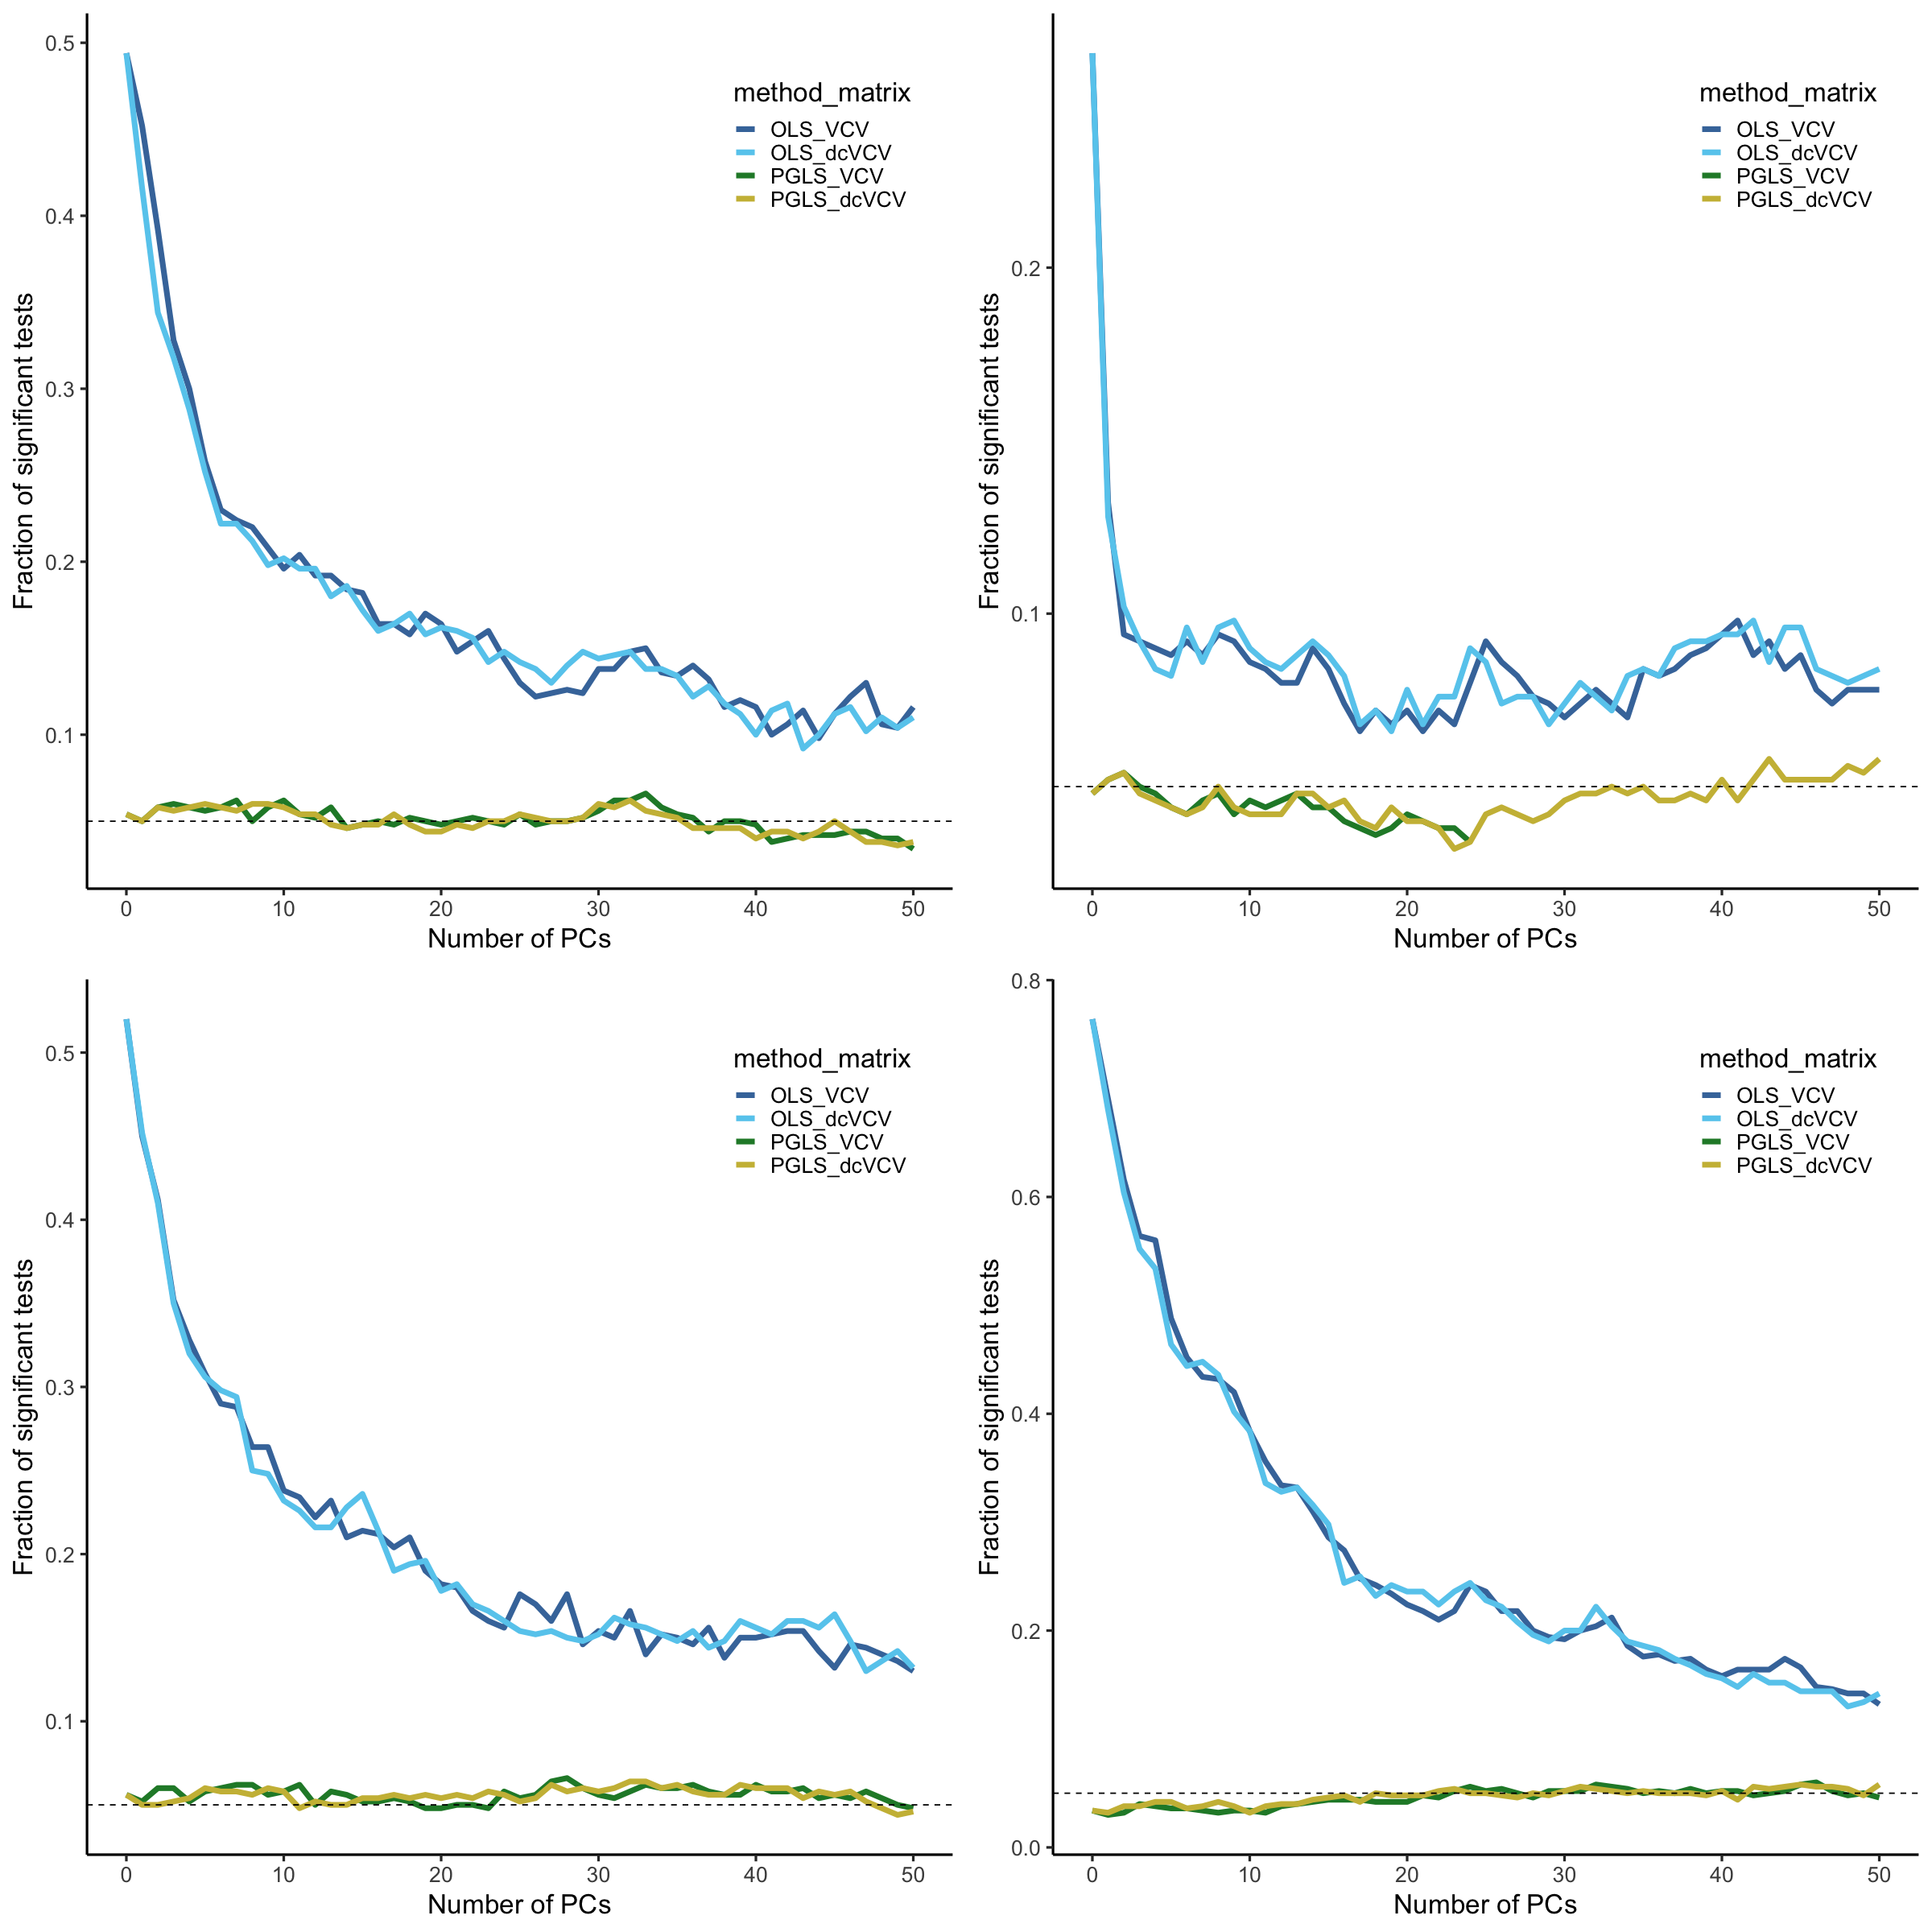

In [17]:
options(repr.plot.width = 20, repr.plot.height = 20)

row1 <- arrangeGrob(plot_1, plot_2, ncol = 2)
row2 <- arrangeGrob(plot_3, plot_4, ncol = 2)

# Arrange all rows into one layout
g <- grid.arrange(row1, row2, nrow = 2)
g
ggsave("Supplmentary_VCV_dcVCV_ultrammetric.pdf", g, width = 20, height = 20)
ggsave("Supplmentary_VCV_dcVCV_ultrammetric.svg", g, width = 20, height = 20)

### 4. Helper functions to create branch lengths for phylogenetic trees

In [18]:
# helper function to create the branch lengths for a tree with n tips

branch_lengths <- function(n, mu, r) {
    set.seed(r)
    branch_lengths = rexp(2 * (n - 1), rate = mu)
    return(branch_lengths)
}

### 5. Showing the performance of VCV and dcVCV

In [20]:
# Pectinate Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_pectinate_2 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = PectinateTree(n_tips)
    tree$edge.length = branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        tryCatch({
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "VCV")]
            }) 

        counter = counter + 1
        
        tryCatch({
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "VCV")]
            })

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))

        tryCatch({
            cur_lm = lm(cur_formula,data=new_all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "lm", "matrix" = "dcVCV")]
            })

        counter = counter + 1

        tryCatch({
            cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            }, error = function(e) {
            p_vals_PC_pectinate_2[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                "method" = "phylolm", "matrix" = "dcVCV")]
            })

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [21]:
p_vals_PC_summary_pectinate_2 = p_vals_PC_pectinate_2 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate_2 = as.data.table(p_vals_PC_summary_pectinate_2) 
p_vals_PC_summary_pectinate_2$method = factor(p_vals_PC_summary_pectinate_2$method)
p_vals_PC_summary_pectinate_2$matrix = factor(p_vals_PC_summary_pectinate_2$matrix)

p_vals_PC_summary_pectinate_2$method_matrix = interaction(p_vals_PC_summary_pectinate_2$method, 
                                                          p_vals_PC_summary_pectinate_2$matrix, 
                                                          sep = "_")

In [22]:
# Balanced Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_balanced_2 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = BalancedTree(n_tips)
    tree$edge.length = branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_balanced_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_balanced_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_balanced_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                           "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [23]:
p_vals_PC_summary_balanced_2 = p_vals_PC_balanced_2 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balanced_2 = as.data.table(p_vals_PC_summary_balanced_2) 
p_vals_PC_summary_balanced_2$method = factor(p_vals_PC_summary_balanced_2$method)
p_vals_PC_summary_balanced_2$matrix = factor(p_vals_PC_summary_balanced_2$matrix)

p_vals_PC_summary_balanced_2$method_matrix = interaction(p_vals_PC_summary_balanced_2$method, 
                                                         p_vals_PC_summary_balanced_2$matrix, 
                                                         sep = "_")

In [24]:
# Coalescent Tree
num_rep = 500
num_PC = 50
n_rows = num_rep * 4 * (num_PC + 1)

p_vals_PC_coal_2 = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    matrix=character(n_rows)
)

counter = 1
for (i in 1:num_rep) {
    if (i %% 20 == 0) {message(i)}

    n_tips = 128
    set.seed(i)
    
    tree = rcoal(n_tips)
    tree$edge.length = branch_lengths(n_tips, 1, i)
    tree$root.edge=0
    PCs = eigen(vcv(tree))$vectors

    colnames(PCs) = paste0("PC_",1:ncol(PCs))
    PCs = as_tibble(PCs)
    
    PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
    PC_sets = c("1",PC_sets)   
    
    BM = fastBM(tree,1,nsim=2)
    X = BM[,1]
    Y = BM[,2]
    
    all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
    rownames(all_data) = rownames(BM)
    
    for (j in 1:length(PC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]

        p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "VCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "VCV")]

        counter = counter + 1
    }

    
    C_N = diag(n_tips) - 1 / n_tips * matrix(1, nrow = n_tips, ncol = n_tips)
    newPCs = eigen(C_N %*% vcv(tree) %*% C_N)$vectors

    colnames(newPCs) = paste0("newPC_",1:ncol(newPCs))
    newPCs = as_tibble(newPCs)

    newPC_sets = lapply(1:num_PC,function(i){paste0("newPC_",1:i)})
    newPC_sets = c("1",newPC_sets)
    
    new_all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),newPCs))
    
    rownames(new_all_data) = rownames(BM)
    
    for (j in 1:length(newPC_sets)) {
        cur_formula = as.formula(paste(c("Y ~ X", newPC_sets[[j]]),collapse=" + "))
        
        cur_lm = lm(cur_formula,data=new_all_data)
        cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
        p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "lm", "matrix" = "dcVCV")]

        counter = counter + 1
        
        cur_lm = phylolm(cur_formula,data=new_all_data,phy=tree)
        cur_p = summary(cur_lm)$coefficients["X","p.value"]
        p_vals_PC_coal_2[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                       "method" = "phylolm", "matrix" = "dcVCV")]

        counter = counter + 1
    }
}

20

40

60

80

100

120

140

160

180

200

220

240

260

280

300

320

340

360

380

400

420

440

460

480

500



In [25]:
p_vals_PC_summary_coal_2 = p_vals_PC_coal_2 %>%
  group_by(method, PCs, matrix) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal_2 = as.data.table(p_vals_PC_summary_coal_2) 
p_vals_PC_summary_coal_2$method = factor(p_vals_PC_summary_coal_2$method)
p_vals_PC_summary_coal_2$matrix = factor(p_vals_PC_summary_coal_2$matrix)

p_vals_PC_summary_coal_2$method_matrix = interaction(p_vals_PC_summary_coal_2$method, 
                                                     p_vals_PC_summary_coal_2$matrix, 
                                                     sep = "_")

### 6. Plotting

In [26]:
plot_5 <- p_vals_PC_summary_pectinate_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.75,.85), legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [27]:
plot_6 <- p_vals_PC_summary_balanced_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.75,.85), legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

In [28]:
plot_7 <- p_vals_PC_summary_coal_2 %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = method_matrix), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of PCs") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.75,.85), legend.spacing.y = unit(1,"pt"), 
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 24)) +
  scale_color_manual(values=c("#4477AA","#66CCEE","#228833","#CCBB44"), 
                     breaks = c("OLS_VCV", "OLS_dcVCV","PGLS_VCV", "PGLS_dcVCV"))

TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

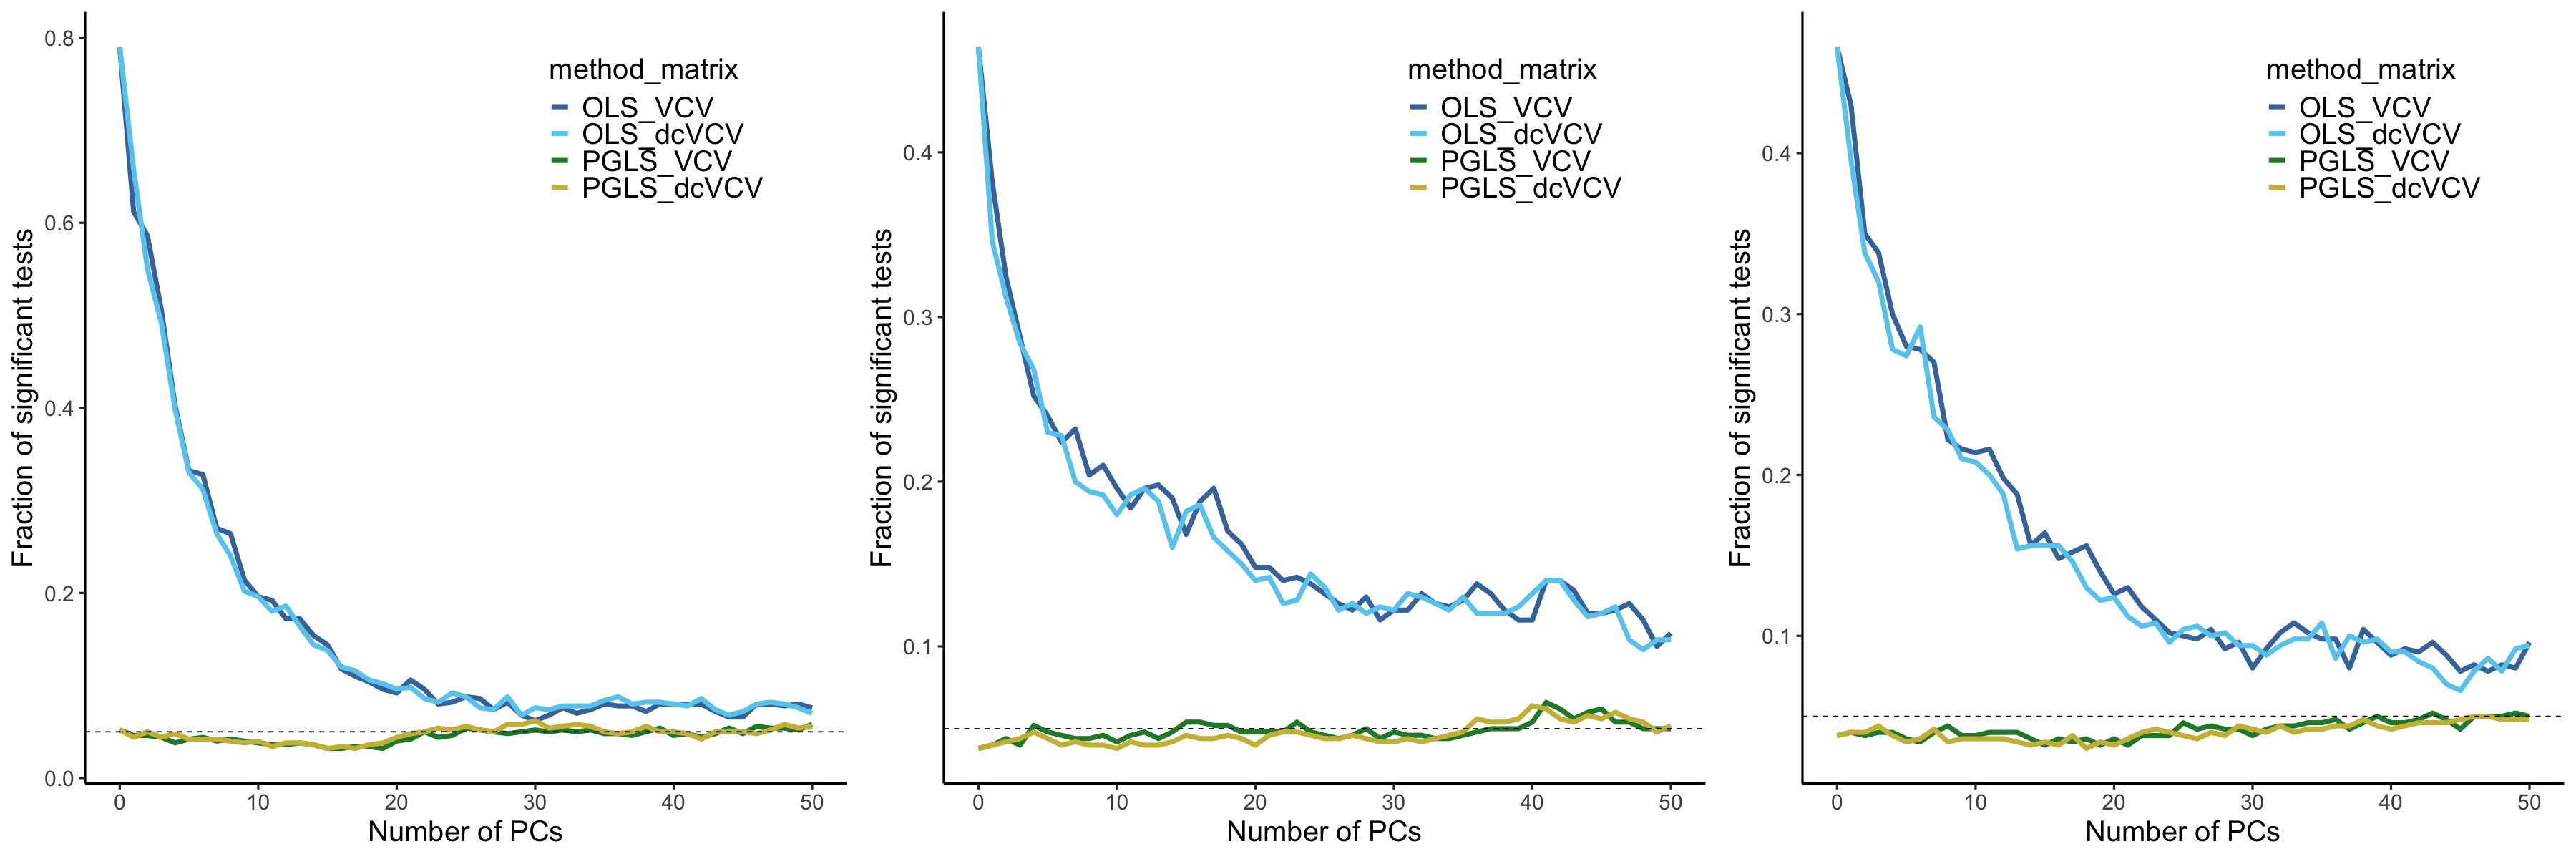

In [29]:
options(repr.plot.width = 30, repr.plot.height = 10)

row1 <- arrangeGrob(plot_5, plot_6, plot_7, ncol = 3)

# Arrange all rows into one layout
g <- grid.arrange(row1, nrow = 1)
g
ggsave("Supplmentary_VCV_dcVCV_nonultra.pdf", g, width = 30, height = 10)
ggsave("Supplmentary_VCV_dcVCV_nonultra.svg", g, width = 30, height = 10)